### Import packages and data

In [2]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
PROJECT_ROOT = Path("/Users/tildeidunsloth/Desktop/Thesis")
SRL_DIR = PROJECT_ROOT / "data" / "SRL"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"

In [4]:
romance_srl = pd.read_csv(SRL_DIR / "romance_srl_cleaned.csv")
lit_fic_srl = pd.read_csv(SRL_DIR / "literary_fiction_srl_cleaned.csv")
sci_fi_srl = pd.read_csv(SRL_DIR / "sci_fi_srl_cleaned.csv")

In [5]:
# combine
df_all = pd.concat([romance_srl, sci_fi_srl, lit_fic_srl], ignore_index=True)

In [6]:
# rename genres
df_all["genre"] = df_all["genre"].replace({
    "romance": "Romance",
    "Literary_fiction": "Literary Fiction",
    "sci_fi": "Science Fiction"
})

In [7]:
# filter out predicates that aren't verbs
non_verbs = ["collar", "ars", "heavier", "knees", "hand closed", "hand covered", "s", "arrival"]

df_all = df_all[~df_all["predicate"].isin(non_verbs)]


In [8]:
# remove predicate_lemma NAs
df_all = df_all.dropna(subset=["predicate_lemma"])

In [9]:
# remove all predicate_lemma = "comm"
df_all = df_all[df_all["predicate_lemma"] != "comm"]

In [10]:
# change predicate_lemma "knitting" to "knit"
df_all.loc[df_all["predicate_lemma"] == "knitting", "predicate_lemma"] = "knit"
df_all.loc[df_all["predicate_lemma"] == "star", "predicate_lemma"] = "stare"
df_all.loc[df_all["predicate_lemma"] == "would", "predicate_lemma"] = "will"
df_all.loc[df_all["predicate_lemma"] == "mistaken", "predicate_lemma"] = "mistake"
df_all.loc[df_all["predicate_lemma"] == "bit", "predicate_lemma"] = "bite"
df_all.loc[df_all["predicate_lemma"] == "offering", "predicate_lemma"] = "offer"
df_all.loc[df_all["predicate_lemma"] == "froze", "predicate_lemma"] = "freeze"

### Plot frequencies for agent, patient and receiver

In [11]:
gender_cols = ["agent_gender", "patient_gender", "receiver_gender"]

df_long = df_all.melt(
    id_vars="genre",
    value_vars=gender_cols,
    var_name="role",
    value_name="gender"
)

df_long["role"] = df_long["role"].str.replace("_gender", "")
df_long = df_long.dropna(subset=["gender"])

In [12]:
# remove mixed gender
df_long = df_long[df_long['gender'] != 'mixed']

In [13]:
df_counts = (
    df_long
    .groupby(["genre", "role", "gender"])
    .size()
    .reset_index(name="count")
)

df_counts["percentage"] = (
    df_counts
    .groupby(["genre", "role"])["count"]
    .transform(lambda x: 100 * x / x.sum())
)

In [14]:
baselines = (
    df_counts[df_counts["gender"] == "male"]
    .groupby("genre")
    .apply(lambda x: (x["percentage"] * x["count"]).sum() / x["count"].sum())
    .to_dict()
)

/var/folders/wv/k1c_2q2x52q536wp2_p2kdpm0000gn/T/ipykernel_73909/3953147716.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["percentage"] * x["count"]).sum() / x["count"].sum())


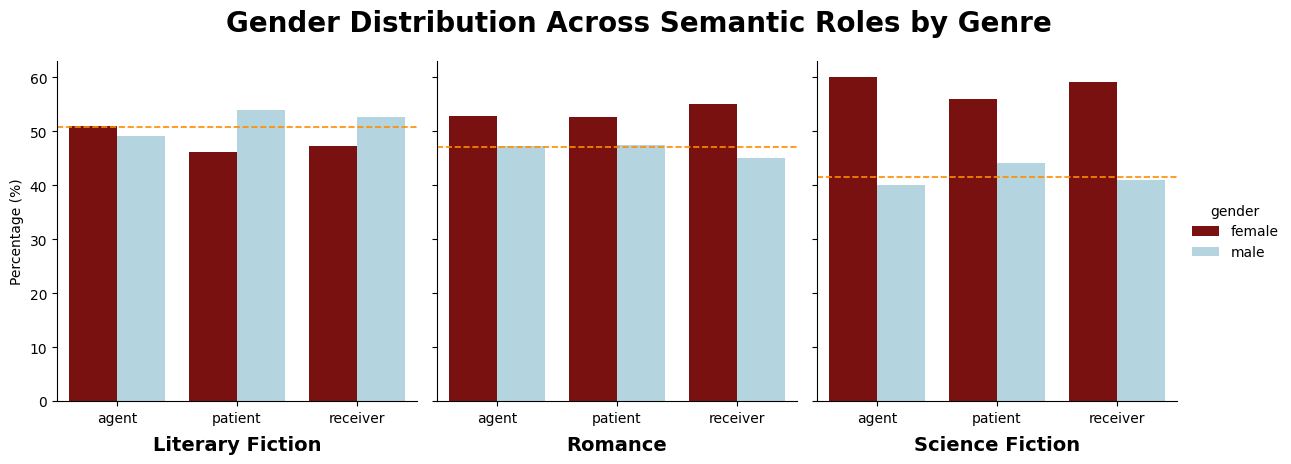

In [ ]:
g = sns.catplot(
    data=df_counts,
    x="role",
    y="percentage",
    hue="gender",
    col="genre",
    kind="bar",
    height=4,
    aspect=1,
    palette=["darkred", "lightblue"]
)

# Add baselines
for ax, title in zip(g.axes.flat, g.col_names):
    baseline = baselines.get(title)
    if baseline is not None:
        ax.axhline(
            y=baseline,
            color="darkorange",
            linestyle="--",
            linewidth=1.2
        )

# Remove default titles
g.set_titles("")

# Add titles below each subplot
for ax, col_name in zip(g.axes.flat, g.col_names):
    ax.text(
        0.5, -0.1, col_name,   # x centered, y below axis
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=14,
        fontweight="bold"
    )

g.set_xlabels("")
g.set_ylabels("Percentage (%)")

g.fig.suptitle(
    "Gender Distribution Across Semantic Roles by Genre",
    fontsize=20,
    fontweight="bold"
)

g.fig.subplots_adjust(top=0.85, bottom=0)

plt.savefig(FIGURES_DIR / "Relational_bias/gender_distribution_across_semantic_roles_by_genre.png", dpi=300)
plt.show()

### Check which predicates each gender are associated with

In [16]:
gender_cols = ["agent_gender", "patient_gender", "receiver_gender"]
role_cols = ["agent", "patient", "receiver"]

# reshape both role + gender together
df_long_pred = pd.concat([
    df_all.assign(role="agent", entity=df_all["agent"], gender=df_all["agent_gender"]),
    df_all.assign(role="patient", entity=df_all["patient"], gender=df_all["patient_gender"]),
    df_all.assign(role="receiver", entity=df_all["receiver"], gender=df_all["receiver_gender"])
])

# keep only relevant columns
df_long_pred = df_long_pred[["genre", "predicate", "predicate_lemma", "role", "gender", "verb_lexname"]]

# drop missing
df_long_pred = df_long_pred.dropna(subset=["gender", "predicate"])

In [17]:
min_count = 10 

df_counts_pred = (
    df_long_pred
    .groupby(["genre", "role", "gender", "predicate_lemma"])
    .size()
    .reset_index(name="count")
)

df_counts_pred["total_predicate"] = (
    df_counts_pred.groupby(["genre", "role", "predicate_lemma"])["count"]
    .transform("sum")
)

df_filtered = df_counts_pred[df_counts_pred["total_predicate"] >= min_count]

# remove gender = mixed
df_filtered = df_filtered[df_filtered["gender"] != "mixed"]

df_filtered["prop"] = (
    df_filtered.groupby(["genre", "role", "predicate_lemma"])["count"]
    .transform(lambda x: x / x.sum())
)

In [18]:
# choose top 10 predicates by proportion for each genre, role, and gender
N = 10

df_top = (
    df_filtered
    .sort_values(
        ["genre", "role", "gender", "prop"],
        ascending=[True, True, True, False]
    )
    .groupby(["genre", "role", "gender"])
    .head(N)
)

In [19]:
df_agents = df_top[df_top["role"] == "agent"]
df_patients = df_top[df_top["role"] == "patient"]
df_receivers = df_top[df_top["role"] == "receiver"] 

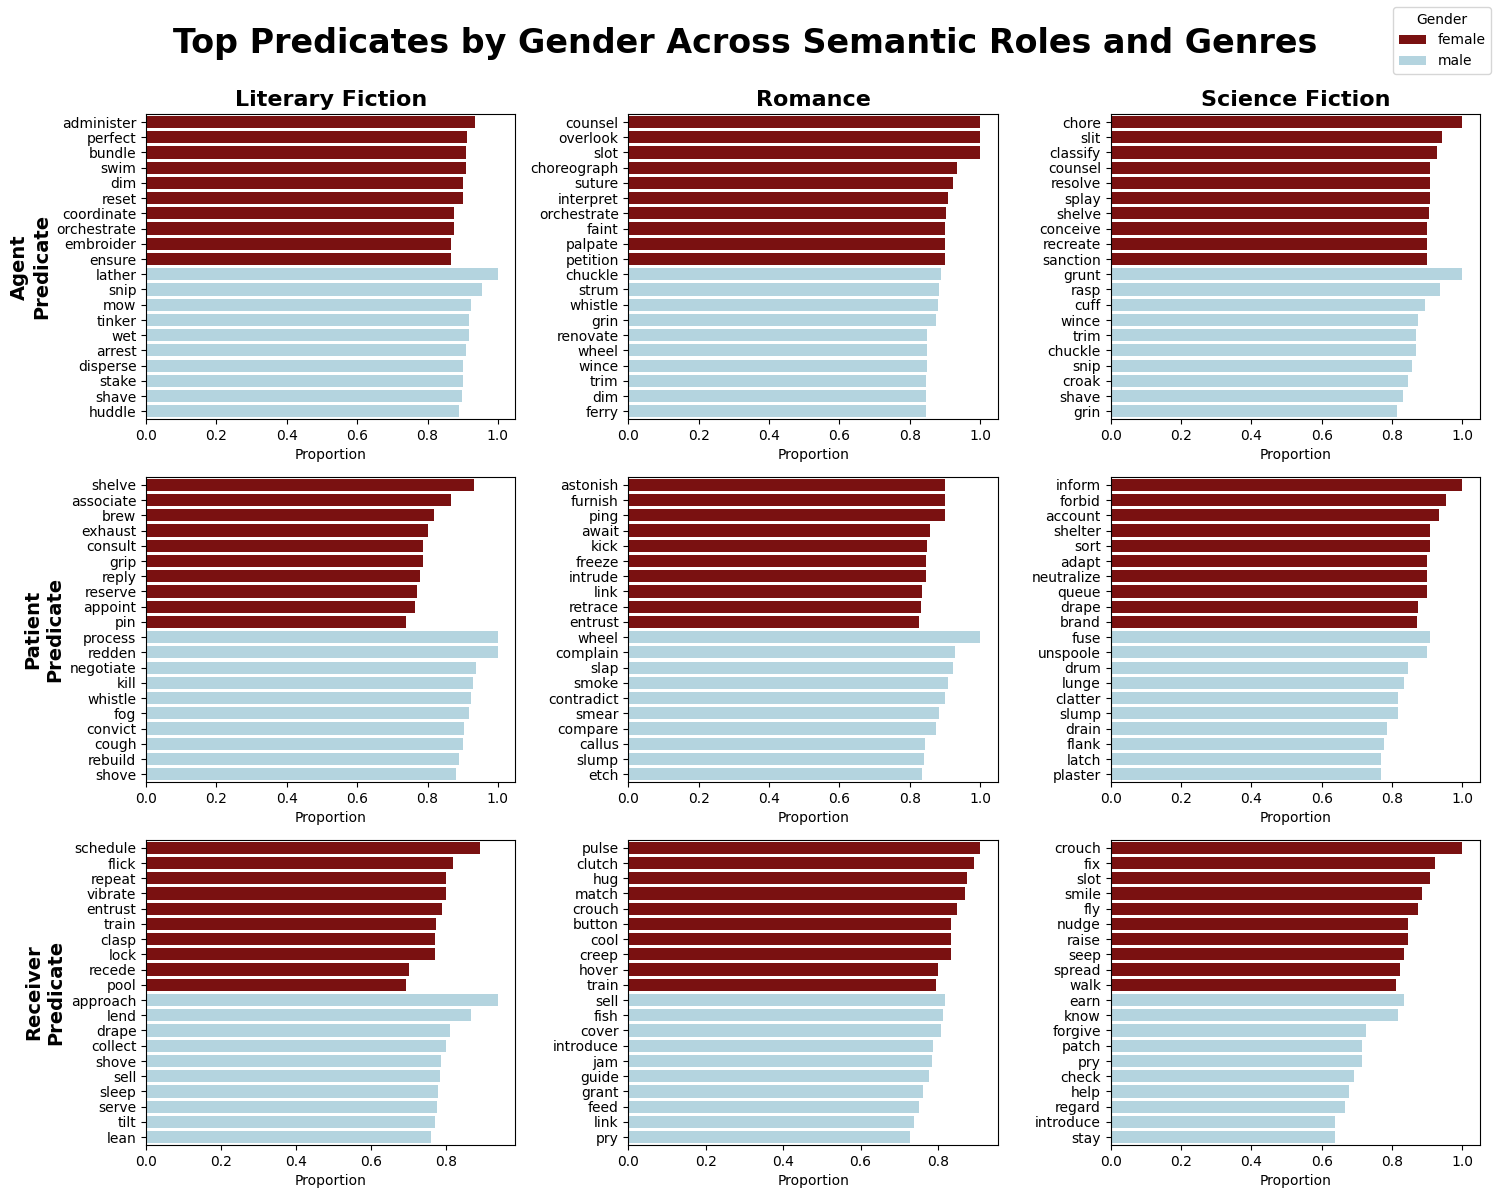

In [ ]:
roles = [
    ("Agent", df_agents),
    ("Patient", df_patients),
    ("Receiver", df_receivers)
]

genres = df_agents["genre"].unique()

fig, axes = plt.subplots(
    nrows=3,
    ncols=len(genres),
    figsize=(5 * len(genres), 12),
    sharex=False
)

for row_idx, (role_name, df_role) in enumerate(roles):
    for col_idx, genre in enumerate(genres):
        
        ax = axes[row_idx, col_idx]
        subdf = df_role[df_role["genre"] == genre]

        sns.barplot(
            data=subdf,
            y="predicate_lemma",
            x="prop",
            hue="gender",
            palette=["darkred", "lightblue"],
            ax=ax
        )

        # Column titles (genres)
        if row_idx == 0:
            ax.set_title(genre, fontsize=16, fontweight="bold")

        # Row labels (roles)
        if col_idx == 0:
            ax.set_ylabel(f"{role_name}\nPredicate", fontsize=14, fontweight="bold")
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Proportion")

        ax.get_legend().remove()


# Global legend (top right)
handles, labels = axes[0, -1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Gender",
    loc="upper right"
)

# Global title
fig.suptitle(
    "Top Predicates by Gender Across Semantic Roles and Genres",
    fontsize=24,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(FIGURES_DIR / "Relational_bias/top_predicates_by_gender_across_roles_genres.png", dpi=300)
plt.show()

### Gender distribution for verb categories

In [21]:
df_long_pred = df_long_pred[df_long_pred["gender"] != "mixed"]

In [22]:
# remove "verb.weather" from verb_lexname
df_long_pred = df_long_pred[df_long_pred["verb_lexname"] != "verb.weather"]

In [23]:
# Binary encode gender (male = 1, female = 0)
df_long_pred["gender_bin"] = (df_long_pred["gender"] == "male").astype(int)

In [24]:
# save to csv
df_long_pred.to_csv(SRL_DIR / "srl_long_format.csv", index=False)

In [25]:
# load plot csv from R
df_plot = pd.read_csv(SRL_DIR / "srl_plot_data.csv")

In [26]:
df_plot["verb_lexname"] = df_plot["verb_lexname"].str.replace("verb.", "", regex=False)

# if stars is NA, replace with empty string
df_plot["stars"] = df_plot["stars"].fillna("")

In [27]:
df_plot_agents = df_plot[df_plot["role"] == "agent"]
df_plot_patients = df_plot[df_plot["role"] == "patient"]
df_plot_receivers = df_plot[df_plot["role"] == "receiver"]

genre_colors = {
    "Literary Fiction": "lightblue", 
    "Romance": "lightcoral",          
    "Science Fiction": "lightgreen"             
}

roles = [
    ("Agent", df_plot_agents),
    ("Patient", df_plot_patients),
    ("Receiver", df_plot_receivers)
]

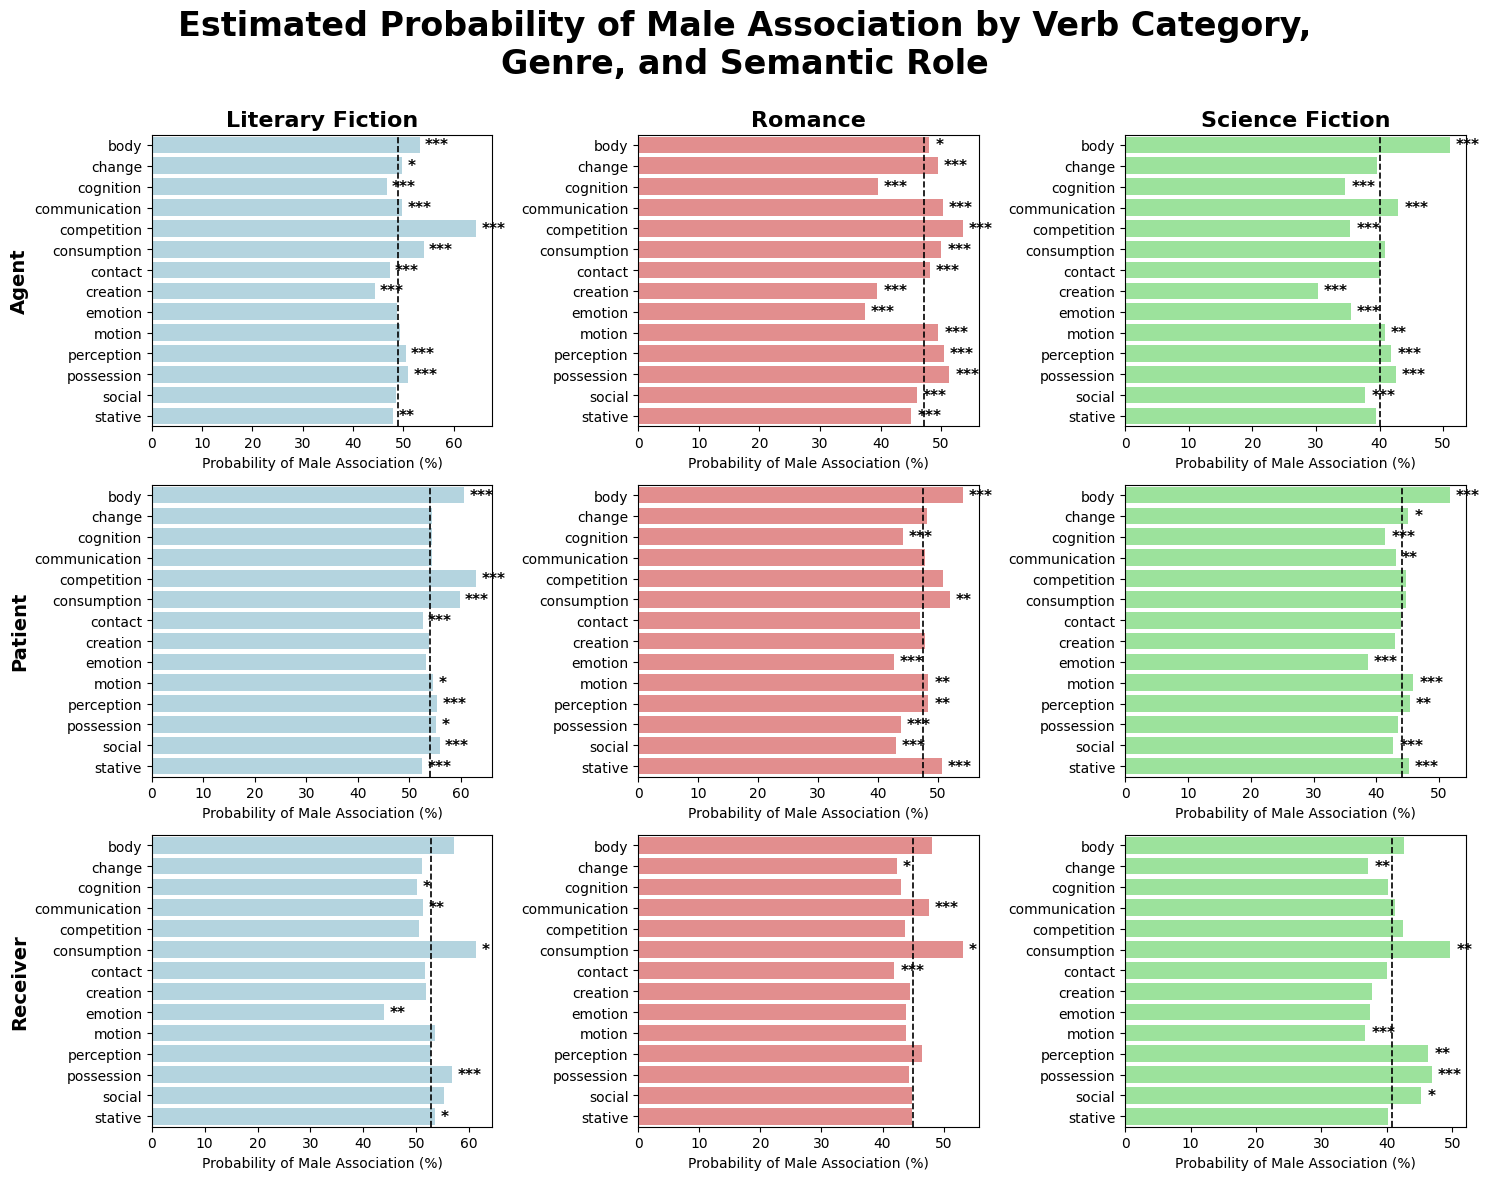

In [29]:
genres = df_plot_agents["genre"].unique()

fig, axes = plt.subplots(
    nrows=3,
    ncols=len(genres),
    figsize=(5 * len(genres), 12),
    sharex=False
)

for row_idx, (role_name, df_role) in enumerate(roles):
    for col_idx, genre in enumerate(genres):
        
        ax = axes[row_idx, col_idx]
        subdf = df_role[df_role["genre"] == genre]
        
        # Get baseline for this genre x role combination
        baseline_val = subdf["p_male_baseline"].iloc[0] * 100

        sns.barplot(
            data=subdf,
            y="verb_lexname",
            x="percent_male",
            hue="genre",
            palette=genre_colors,
            ax=ax
        )

        # Add baseline reference line
        ax.axvline(
            x=baseline_val,
            color="black",
            linestyle="--",
            linewidth=1.2,
            label=f"Baseline ({baseline_val:.0f}%)"
        )

        # Titles
        if row_idx == 0:
            ax.set_title(genre, fontsize=16, fontweight="bold")

        if col_idx == 0:
            ax.set_ylabel(f"{role_name}", fontsize = 14, fontweight="bold")
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Probability of Male Association (%)")

        # Remove redundant legends
        ax.get_legend().remove()

        # Add stars
        order = [t.get_text() for t in ax.get_yticklabels()]

        for i, verb in enumerate(order):
            row = subdf[subdf["verb_lexname"] == verb].iloc[0]
            star = row["stars"]

            if pd.isna(star) or star == "" or star == "nan":
                continue

            ax.text(
                row["percent_male"] + 1.0,
                i,
                star,
                va="center",
                ha="left",
                fontsize=11,
                fontweight="bold"
            )

# Global title
fig.suptitle(
    "Estimated Probability of Male Association by Verb Category,\nGenre, and Semantic Role",
    fontsize=24,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(FIGURES_DIR / "Relational_bias/estimated_probability_of_male_association_by_verb_category_genre_role.png", dpi=300)
plt.show()